<a href="https://colab.research.google.com/github/leejuheon06/Practice_ML_1/blob/main/09_CNN%EC%9D%84_%ED%99%9C%EC%9A%A9%ED%95%9C_%EC%9D%B4%EB%AF%B8%EC%A7%80_%EC%9D%B8%EC%8B%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [ ]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

In [ ]:
# 세션 다시 시작 후 진행

# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [ ]:
# 파이토치 관련 라이브러리

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


9.4 파이토치에서 CNN 구현하는 방법

In [ ]:
# CNN 모델 전반 부분, 레이어 함수 정의

conv1 = nn.Conv2d(3, 32, 3)
relu = nn.ReLU(inplace=True)
conv2 = nn.Conv2d(32, 32, 3)
maxpool = nn.MaxPool2d((2,2))

In [ ]:
print(conv1)

print(conv1.weight.shape)
print(conv1.bias.shape)

print(conv2.weight.shape)
print(conv2.bias.shape)

Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
torch.Size([32, 3, 3, 3])
torch.Size([32])
torch.Size([32, 32, 3, 3])
torch.Size([32])


In [ ]:
# 더미로 입력과 같은 사이즈를 갖는 텐서를 생성
inputs = torch. randn(100, 3, 32, 32)   # batch, channel, h, w
print(inputs.shape)

torch.Size([100, 3, 32, 32])


In [ ]:
# CNN 전반부 처리 시뮬레이션
x1 = conv1(inputs)
x2 = relu(x1)
x3 = conv2(x2)
x4 = relu(x3)
x5 = maxpool(x4)

In [ ]:
print(inputs.shape)
print(x1.shape)
print(x2.shape)
print(x3.shape)
print(x4.shape)
print(x5.shape)

torch.Size([100, 3, 32, 32])
torch.Size([100, 32, 30, 30])
torch.Size([100, 32, 30, 30])
torch.Size([100, 32, 28, 28])
torch.Size([100, 32, 28, 28])
torch.Size([100, 32, 14, 14])


In [ ]:
# 함수 정의
features = nn.Sequential(conv1, relu, conv2, relu, maxpool)

In [ ]:
outputs = features(inputs)
print(outputs.shape)

torch.Size([100, 32, 14, 14])


In [ ]:
# 함수 정의
flatten = nn.Flatten()

# 동작 테스트
outputs2 = flatten(outputs)

# 결과 확인
print(outputs.shape)
print(outputs2.shape)

torch.Size([100, 32, 14, 14])
torch.Size([100, 6272])


9.5 공통 함수 사용하기

In [ ]:
# 손실 계산용
def eval_loss(loader, device, net, criterion):
    for images, labels in loader:
        break

    # 디바이스 전달
    inputs = images.to(device)
    labels = labels.to(device)

    # 예측 계산
    outputs = net(inputs)

    # 손실 계산
    loss = criterion(outputs, labels)

    return loss

In [ ]:
# fit(학습)
def fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history):

    from tqdm.notebook import tqdm

    base_epochs = len(history)

    for epoch in range(base_epochs, num_epochs + base_epochs):
        train_loss = 0
        train_acc = 0
        val_loss = 0
        val_acc = 0

        # 훈련 페이즈
        net.train()
        count = 0

        for inputs, labels in tqdm(train_loader):
            count += len(labels)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # 경사 초기화
            optimizer.zero_grad()
            # 예측
            outputs = net(inputs)
            # 손실 계산
            loss = criterion(outputs, labels)
            train_loss += loss.item()
            # 경사 계산
            loss.backward()
            # 파라미터 수정
            optimizer.step()
            # 예측 라벨 산출
            predicted = torch.max(outputs, 1)[1]
            # 정답 건수(acc)
            train_acc += (predicted == labels).sum().item()
            # 손실과 정확도 계산
            avg_train_loss = train_loss / count
            avg_train_acc = train_acc / count

        # 예측 페이즈
        net.eval()
        count=0

        for inputs, labels in test_loader:
            count += len(labels)
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            predicted = torch.max(outputs, 1)[1]

            val_acc += (predicted == labels).sum().item()

            avg_val_loss = val_loss / count
            avg_val_acc = val_acc / count

        print(f'Epoch [{(epoch+1)}/{num_epochs+base_epochs}], '
              f'loss: {avg_train_loss:.4f}, acc: {avg_train_acc:.4f}, '
              f'val_loss: {avg_val_loss:.4f}, acc: {avg_val_acc:.4f}')

        item = np.array([epoch + 1, avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc])
        history = np.vstack((history, item))

    return history

In [ ]:
# eval_history(학습 로그)

def evaluate_history(history):
    # 손실과 정확도 확인
    print(f'초기상태 : 손실 : {history[0,3]:.5f}  정확도 : {history[0,4]:.5f}')
    print(f'최종상태 : 손실 : {history[-1,3]:.5f}  정확도 : {history[-1,4]:.5f}' )

    num_epochs = len(history)
    unit = num_epochs / 10

    # 학습 곡선 출력(손실)
    plt.figure(figsize=(9,8))
    plt.plot(history[:,0], history[:,1], 'b', label='훈련')
    plt.plot(history[:,0], history[:,3], 'k', label='검증')
    plt.xticks(np.arange(0,num_epochs+1, unit))
    plt.xlabel('반복 횟수')
    plt.ylabel('손실')
    plt.title('학습 곡선(손실)')
    plt.legend()
    plt.show()

    # 학습 곡선 출력(정확도)
    plt.figure(figsize=(9,8))
    plt.plot(history[:,0], history[:,2], 'b', label='훈련')
    plt.plot(history[:,0], history[:,4], 'k', label='검증')
    plt.xticks(np.arange(0,num_epochs+1,unit))
    plt.xlabel('반복 횟수')
    plt.ylabel('정확도')
    plt.title('학습 곡선(정확도)')
    plt.legend()
    plt.show()

In [ ]:
# show_images_labels (예측결과 표시)

# 이미지와 라벨 표시
def show_images_labels(loader, classes, net, device):
    # 데이터 로더에서 처음 1세트 가져오기
    for images, labels in loader:
        break
    # 표시 수는 50개
    n_size = min(len(images), 50)

    if net is not None:
        inputs = images.to(device)
        labels = labels.to(device)

        # 예측 계산
        outputs = net(inputs)
        predicted = torch.max(outputs, 1)[1]

    # 처음 n_size개 표시
    plt.figure(figsize=(20, 15))
    for i in range(n_size):
        ax = plt.subplot(5, 10, i + 1)
        label_name = classes[labels[i]]
        # net이 None이 아닌 경우는 예측 결과도 타이틀에 표시함
        if net is not None:
          predicted_name = classes[predicted[i]]
          # 정답인지 아닌지 색으로 구분함
          if label_name == predicted_name:
            c = 'k'
          else:
            c = 'b'
          ax.set_title(label_name + ':' + predicted_name, c=c, fontsize=20)
        # net이 None인 경우는 정답 라벨만 표시
        else:
          ax.set_title(label_name, fontsize=20)
        # 텐서를 넘파이로 변환
        image_np = images[i].numpy().copy()
        # 축의 순서 변경 (channel, row, column) -> (row, column, channel)
        img = np.transpose(image_np, (1, 2, 0))
        # 값의 범위를[-1, 1] -> [0, 1]로 되돌림
        img = (img + 1)/2
        # 결과 표시
        plt.imshow(img)
        ax.set_axis_off()
    plt.show()

In [ ]:
# 파이토치 난수 고정

def torch_seed(seed=123):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms = True

9.6 데이터 준비

In [ ]:
# 데이터 준비
# transforms 정의

# transform1 : 1계 텐서화
transform1 = transforms.Compose([
    transforms.ToTensor(),                     # 넘파이 배열 >> 텐서로 변환 [0,1]
    transforms.Normalize(0.5 , 0.5),           # 평균 0.5, 표준편차 0.5 정규화 >> 데이터를 [-1,1] 범위 변환
    transforms.Lambda(lambda x: x.view(-1))    # view(-1): 텐서를 1차원으로 평탄화
])

# transform2 : 정규화만 실시
transform2 = transforms.Compose([
    transforms.ToTensor(),                     # 넘파이 배열 >> 텐서로 변환 [0,1]
    transforms.Normalize(0.5 , 0.5),           # 평균 0.5, 표준편차 0.5 정규화 >> 데이터를 [-1,1] 범위 변환
])

In [ ]:
# 데이터 취득용 함수 datasets

data_root = './data'

# 훈련 데이터셋(1계 텐서 버전)
train_set1 = datasets.CIFAR10(
    root = data_root, train=True,
    download=True, transform = transform1
)

# 검증 데이터셋(1계 텐서 버전)
test_set1 = datasets.CIFAR10(
    root = data_root, train=False,
    download=True, transform = transform1
)

# 훈련 데이터셋(CNN용(3계 텐서 버전))
train_set2 = datasets.CIFAR10(
    root = data_root, train=True,
    download=True, transform = transform2
)

# 검증 데이터셋(3계 텐서 버전)
test_set2 = datasets.CIFAR10(
    root = data_root, train=False,
    download=True, transform = transform2
)

100%|██████████| 170M/170M [01:41<00:00, 1.68MB/s]


In [ ]:
image1, label1 = train_set1[0]
image2, label2 = train_set2[0]

print(image1.shape)
print(image2.shape)

torch.Size([3072])
torch.Size([3, 32, 32])


In [ ]:
# 데이터 로더 정의

# 미니 배치 사이즈 지정
batch_size = 100

# 훈련용 데이터 로더
# shuffle = True 설정
train_loader1 = DataLoader(train_set1, batch_size=batch_size, shuffle=True)

# 검증용 데이터 로더
# shuffle = False
test_loader1 = DataLoader(test_set1, batch_size=batch_size, shuffle=False)

# 훈련용 데이터 로더
# shuffle = True 설정
train_loader2 = DataLoader(train_set2, batch_size=batch_size, shuffle=True)

# 검증용 데이터 로더
# shuffle = False
test_loader2 = DataLoader(test_set2, batch_size=batch_size, shuffle=False)

In [ ]:
for images1, labels1 in train_loader1:
    break

for images2, labels2 in train_loader2:
    break

print(images1.shape)
print(images2.shape)

torch.Size([100, 3072])
torch.Size([100, 3, 32, 32])


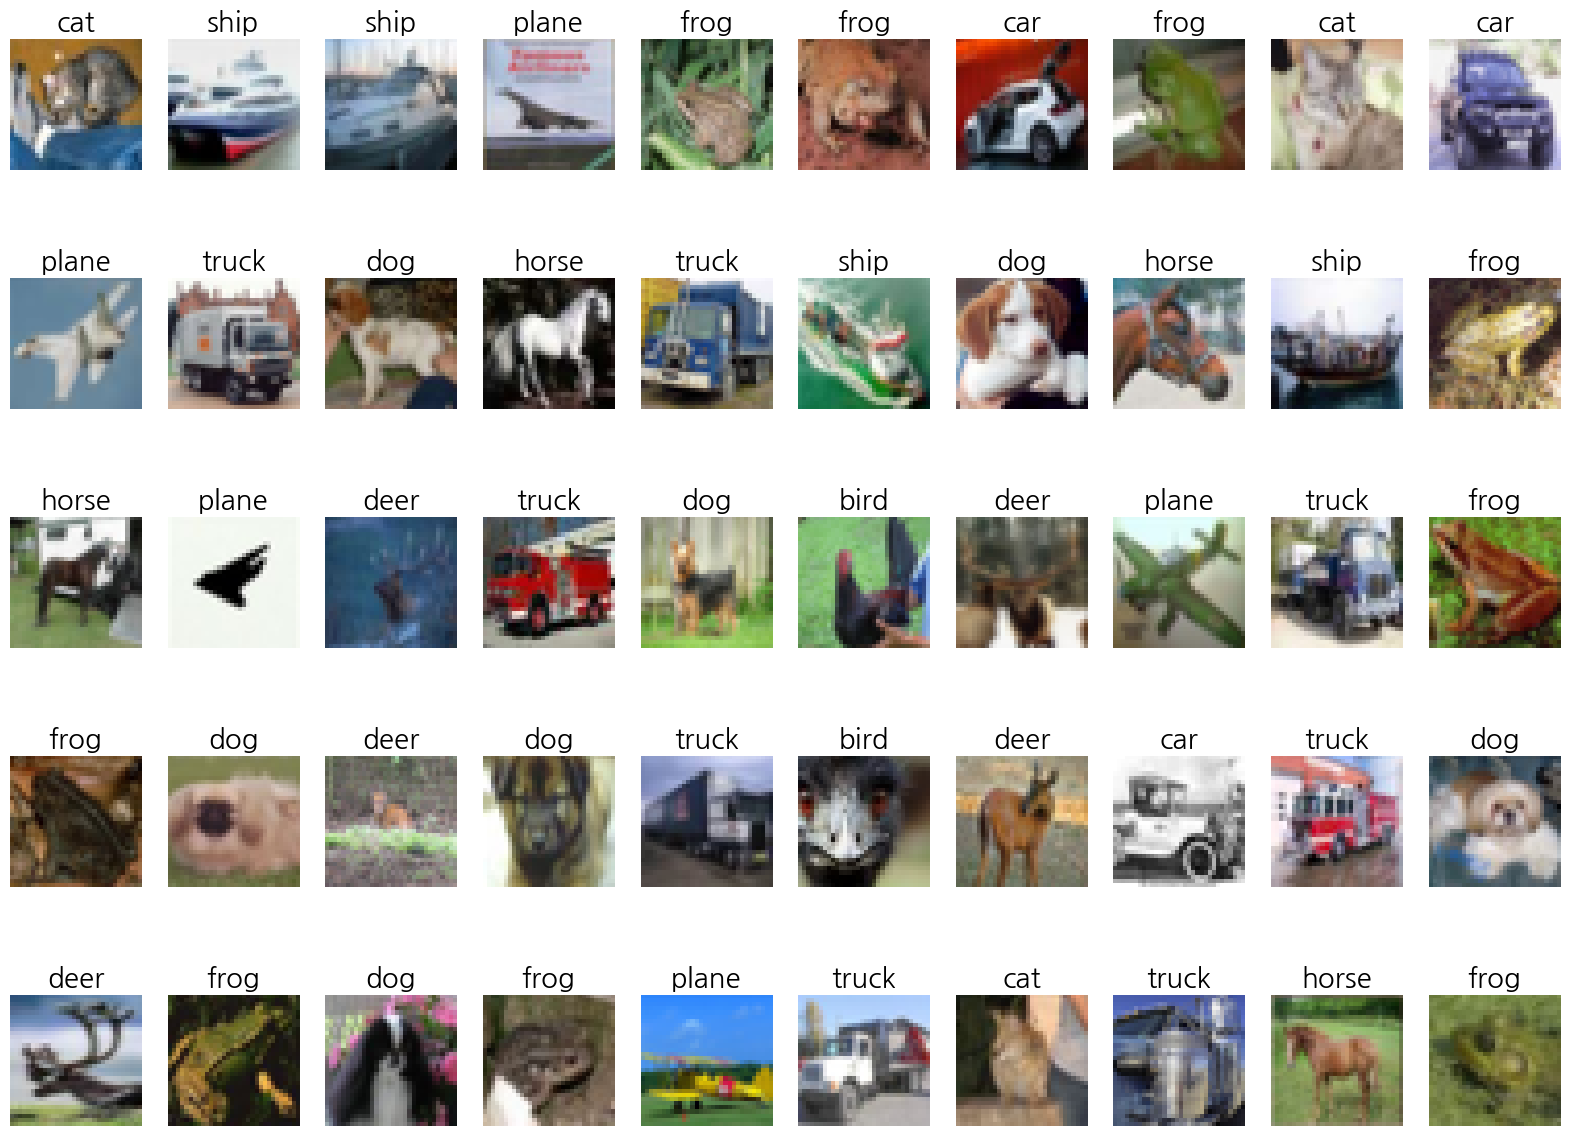

In [ ]:
# 정답 라벨 정의
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 검증 데이터의 처음 50개를 출력
show_images_labels(test_loader2, classes, None, None)
# show_images_labels(검증용 데이터, 클래스 이름, 예측값, 모델 객체)

9.7 모델 정의(전결합형)

In [ ]:
# 입력 차원 수
n_input = image1.view(-1).shape[0]

# 출력 차원 수 (분류 클래스 10개)
# labels1 # 텐서
# labels1.data.numpy() # 넘파이 변환
n_output = len(set(list(labels1.data.numpy())))

# 은닉층 노드 수
n_hidden = 128

# 결과 확인
print(f'n_input: {n_input}')
print(f'n_output: {n_output}')
print(f'n_hidden: {n_hidden}')

n_input: 3072
n_output: 10
n_hidden: 128


In [ ]:
# 모델정의
# 3072 입력 10 출력, 1 은닉층 신경망 모델

class Net(nn.Module):
    def __init__(self, n_input, n_output, n_hidden):
        super().__init__()

        # 은닉층 정의(n_hidden)
        self.l1 = nn.Linear(n_input, n_hidden)

        # 출력층 정의
        self.l2 = nn.Linear(n_hidden, n_output)

        # 활성화 함수 정의
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.relu(x1)
        x3 = self.l2(x2)
        return x3

9.8 결과(전결합형)

In [ ]:
# 완전 결합형 모델 초기화와 학습
torch.seed() # 난수 초기화

net = Net(n_input, n_hidden, n_output).to(device)
criterion = nn.CrossEntropyLoss()

lr = 0.01
optimizer = optim.SGD(net.parameters(), lr=lr)
num_epochs = 50
history = np.zeros((0,5))

In [ ]:
# 학습
history = fit(net, optimizer, criterion, num_epochs, train_loader1, test_loader1, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.0299, acc: 0.2154, val_loss: 0.0212, acc: 0.3006


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.0200, acc: 0.3263, val_loss: 0.0192, acc: 0.3443


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.0158, acc: 0.4390, val_loss: 0.0164, acc: 0.4155


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.0158, acc: 0.4386, val_loss: 0.0164, acc: 0.4156


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.0157, acc: 0.4389, val_loss: 0.0164, acc: 0.4188


초기상태 : 손실 : 0.02124  정확도 : 0.30060
최종상태 : 손실 : 0.01635  정확도 : 0.41880


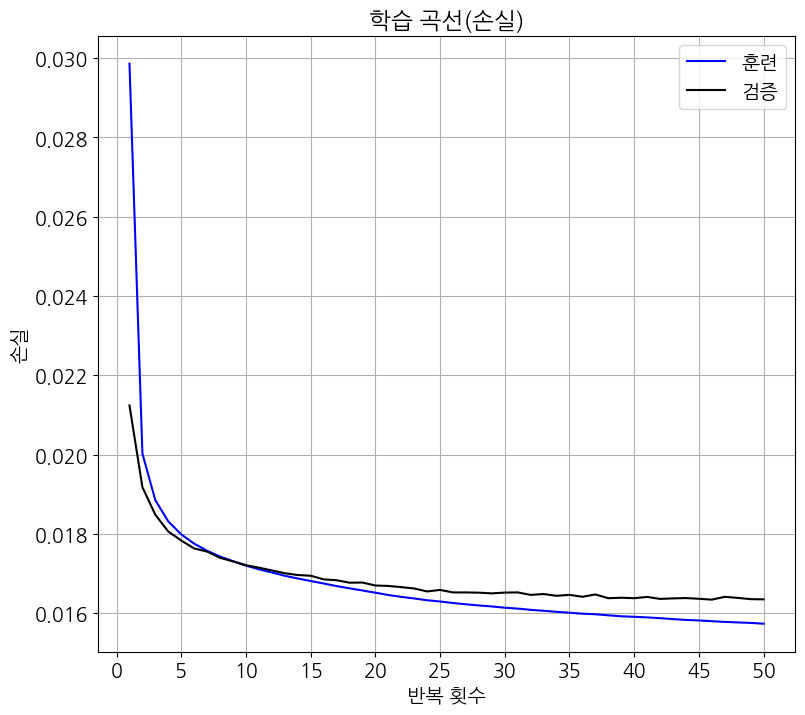

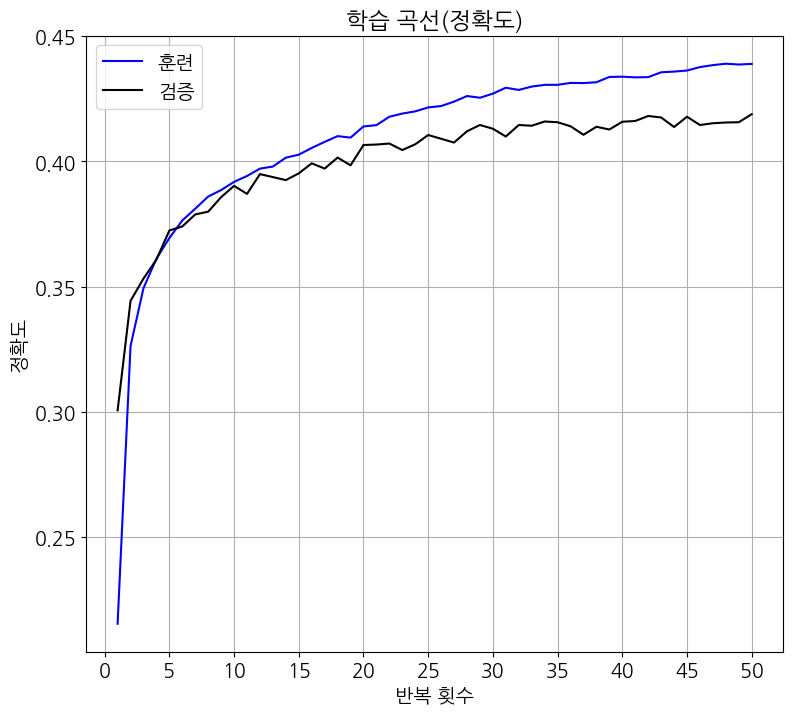

In [ ]:
# 평가
evaluate_history(history)

9.9 모델 정의(CNN)

In [ ]:
class CNN(nn.Module):
    def __init__(self, n_output, n_hidden):
        super().__init__()
        # 특징 추출(feature extraction)
        self.conv1 = nn.Conv2d(3, 32, 3)     # 3 (rgb) 32채널(피처맵 개수) 3(3*3 커널)
        self.conv2 = nn.Conv2d(32, 32, 3)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d((2,2))

        self.flatten = nn.Flatten()
        # 분류기 (classifier: clf)
        self.l1 = nn.Linear(6272, n_hidden)
        self.l2 = nn.Linear(n_hidden, n_output)

        # 역할별로 그룹화
        self.features = nn.Sequential(
            self.conv1, self.relu, self.conv2, self.maxpool)

        self.classifier = nn.Sequential(
            self.l1, self.relu, self.l2)

    # 조립라인: 데이터 흐름 정의
    def forward(self, x):
        x1 = self.features(x)   # 특징 추출
        x2 = self.flatten(x1)   # 1차원으로 쭉 펼치기
        x3 = self.classifier(x2)# 최종분류
        return x3

In [ ]:
# 모델 인스턴스 생성
net = CNN(n_output, n_hidden).to(device)

# 손실함수
criterion = nn.CrossEntropyLoss()

lr = 0.01
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

In [ ]:
print(net)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (l1): Linear(in_features=6272, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=10, bias=True)
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=6272, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


9.10 결과(CNN)

In [ ]:
# CNN 모델 초기화 및 학습

torch_seed()

net = CNN(n_output, n_hidden).to(device)
criterion = nn.CrossEntropyLoss()

lr = 0.01
optimizer = optim.SGD(net.parameters(), lr=lr)

num_epochs = 50
history2 = np.zeros((0,5))

In [ ]:
# 학습
history2 = fit(net, optimizer, criterion, num_epochs, train_loader2, test_loader2, device, history2)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.0204, acc: 0.2784, val_loss: 0.0183, acc: 0.3605


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.0172, acc: 0.3985, val_loss: 0.0159, acc: 0.4398


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.0002, acc: 0.9987, val_loss: 0.0211, acc: 0.6385


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.0002, acc: 0.9989, val_loss: 0.0217, acc: 0.6422


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.0002, acc: 0.9995, val_loss: 0.0218, acc: 0.6425


초기상태 : 손실 : 0.01833  정확도 : 0.36050
최종상태 : 손실 : 0.02178  정확도 : 0.64250


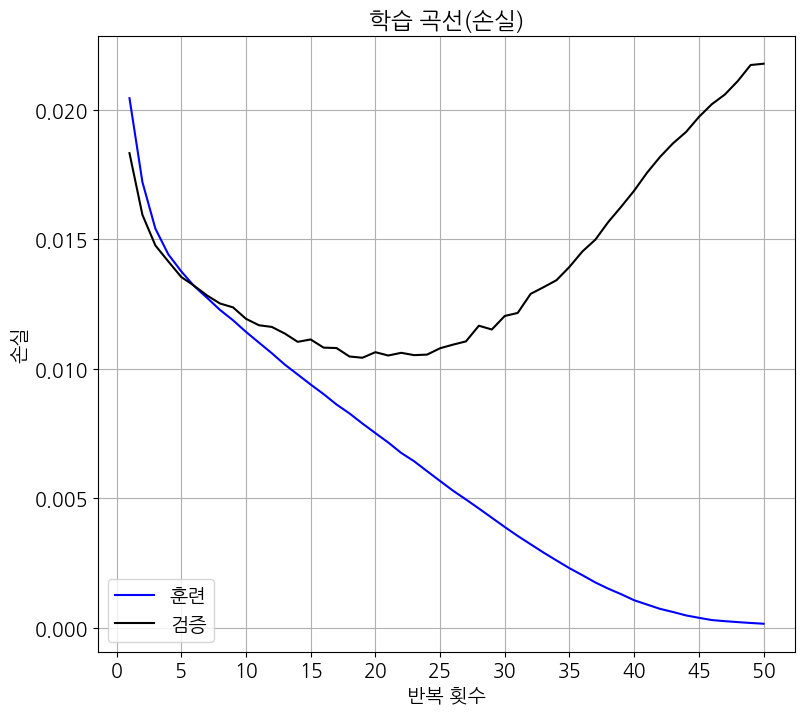

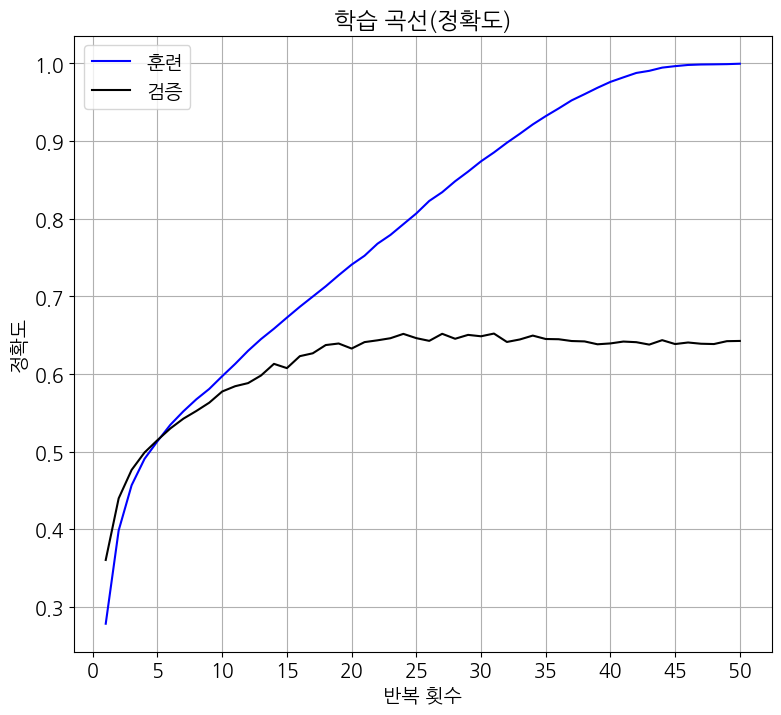

In [ ]:
# 평가
evaluate_history(history2)
# 과적합 발생
# 다음 장에서 튜닝을 통해 모델의 정확도 향상시켜 볼 것

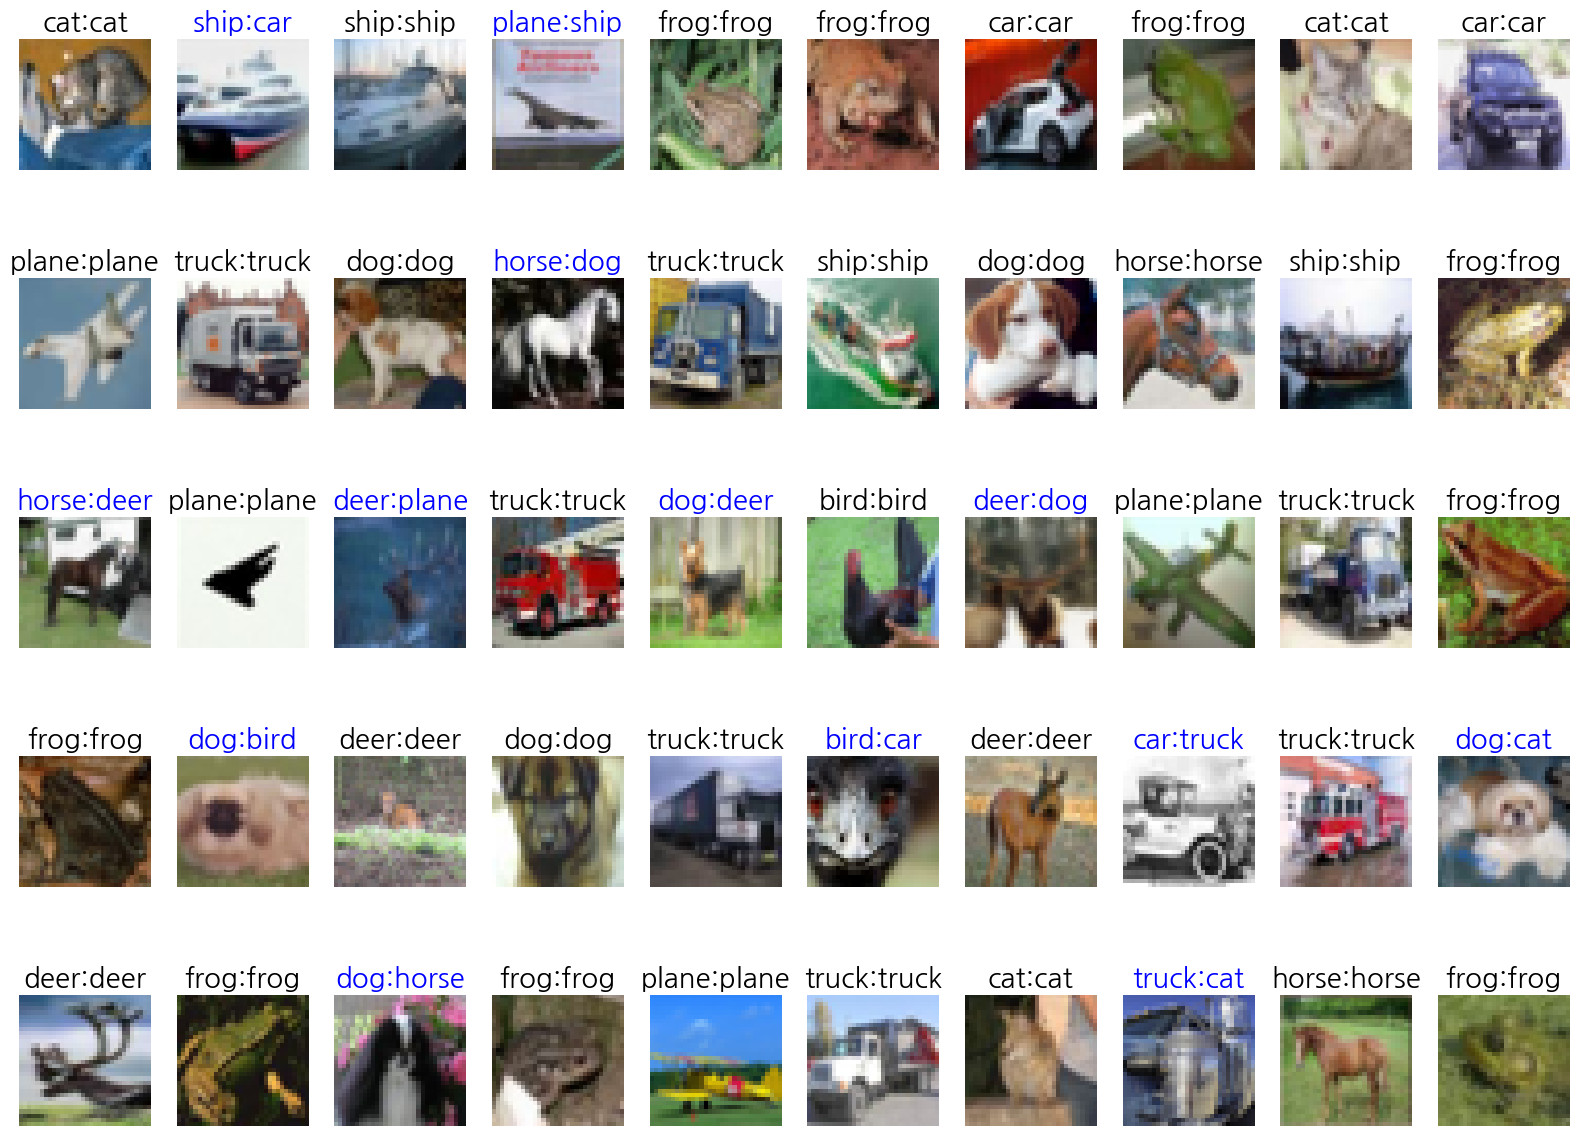

In [ ]:
# 처음 50 개 데이터 표시
show_images_labels(test_loader2, classes, net, device)

In [ ]:
# eos